This ipynb file is made to add perturbations (audio intensity) to the selected .wav files (with already Wiener filter)
 

In [50]:
# Standard libraries
from pathlib import Path
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import shutil


from scipy.io import wavfile
from scipy.signal import wiener

# load data
DATA_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME")
WIENER_INPUT_DIR = DATA_PATH / "wiener_filtered_audio_pain"
INTENSITY_OUTPUT_DIR = DATA_PATH / "wiener_intensity_perturbations_pain"

INTENSITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [51]:
#collect wav files
wiener_audio_files = []

for root, dirs, files in os.walk(WIENER_INPUT_DIR):
    for file in files:
        if file.endswith(".wav"):
            wiener_audio_files.append(os.path.join(root, file))

print(f"Number of Wiener-filtered audio files: {len(wiener_audio_files)}")

Number of Wiener-filtered audio files: 1055


In [52]:
def load_wav_file(file_path):
    """
    Load a WAV file and return sample rate and signal.
    """
    sample_rate, signal = wavfile.read(file_path)
    return sample_rate, signal


def save_wav_file(file_path, sample_rate, signal):
    """
    Save a WAV file as int16.
    """
    signal = np.clip(signal, -32768, 32767) #so the signal remains in the 16 bit format 
    signal = signal.astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)

def change_audio_intensity(signal, gain_db):
    """
    Change audio intensity by applying gain in dB.

    Parameters
    signal : np.ndarray
        Input audio signal
    gain_db : float
        Gain in decibels

    Returns
    adjusted_signal : np.ndarray
        Intensity-adjusted audio signal
    """
    signal = signal.astype(np.float32)

    # Convert dB to linear amplitude factor
    gain_factor = 10 ** (gain_db / 20.0)

    adjusted_signal = signal * gain_factor
    return adjusted_signal


def make_perturbation_output_path(input_path, input_root, output_root, perturbation_name):
    """
    Save perturbed audio in:
    output_root / perturbation_name / PID / original_filename.wav
    """
    relative_path = os.path.relpath(input_path, input_root)
    output_path = os.path.join(output_root, perturbation_name, relative_path)

    output_dir = os.path.dirname(output_path)
    os.makedirs(output_dir, exist_ok=True)

    return output_path

In [53]:
# dB steps
step_dB = 3

perturbations = {
    "-6dB": -2 * step_dB,   # -6 dB
    "-3dB":  -1 * step_dB,   # -3 dB
    "+3dB":    1 * step_dB,   # +3 dB
    "+6dB":   2 * step_dB    # +6 dB
}


In [54]:
#save the different levels of dB in a new map 
processed_rows = []

for input_path in wiener_audio_files:
    try:
        sample_rate, signal = load_wav_file(input_path)

        for perturbation_name, gain_db in perturbations.items():
            adjusted_signal = change_audio_intensity(signal, gain_db)

            output_path = make_perturbation_output_path(
                input_path=input_path,
                input_root=WIENER_INPUT_DIR,
                output_root=INTENSITY_OUTPUT_DIR,
                perturbation_name=perturbation_name
            )

            save_wav_file(output_path, sample_rate, adjusted_signal)

            participant_id = os.path.basename(os.path.dirname(input_path))
            filename = os.path.basename(input_path)

            processed_rows.append({
                "participant_id": participant_id,
                "filename": filename,
                "original_wiener_file_path": input_path,
                "perturbation": perturbation_name,
                "gain_db": gain_db,
                "perturbed_file_path": output_path
            })

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

print(os.path.exists(input_path))

True


In [55]:
#check if number of processed files is correct
expected_files_per_perturbation = len(wiener_audio_files)
for perturbation_name in perturbations.keys():
    count = sum(1 for row in processed_rows if row["perturbation"] == perturbation_name)
    print(f"Number of files processed for {perturbation_name}: {count} (Expected: {expected_files_per_perturbation})")


Number of files processed for -6dB: 1055 (Expected: 1055)
Number of files processed for -3dB: 1055 (Expected: 1055)
Number of files processed for +3dB: 1055 (Expected: 1055)
Number of files processed for +6dB: 1055 (Expected: 1055)


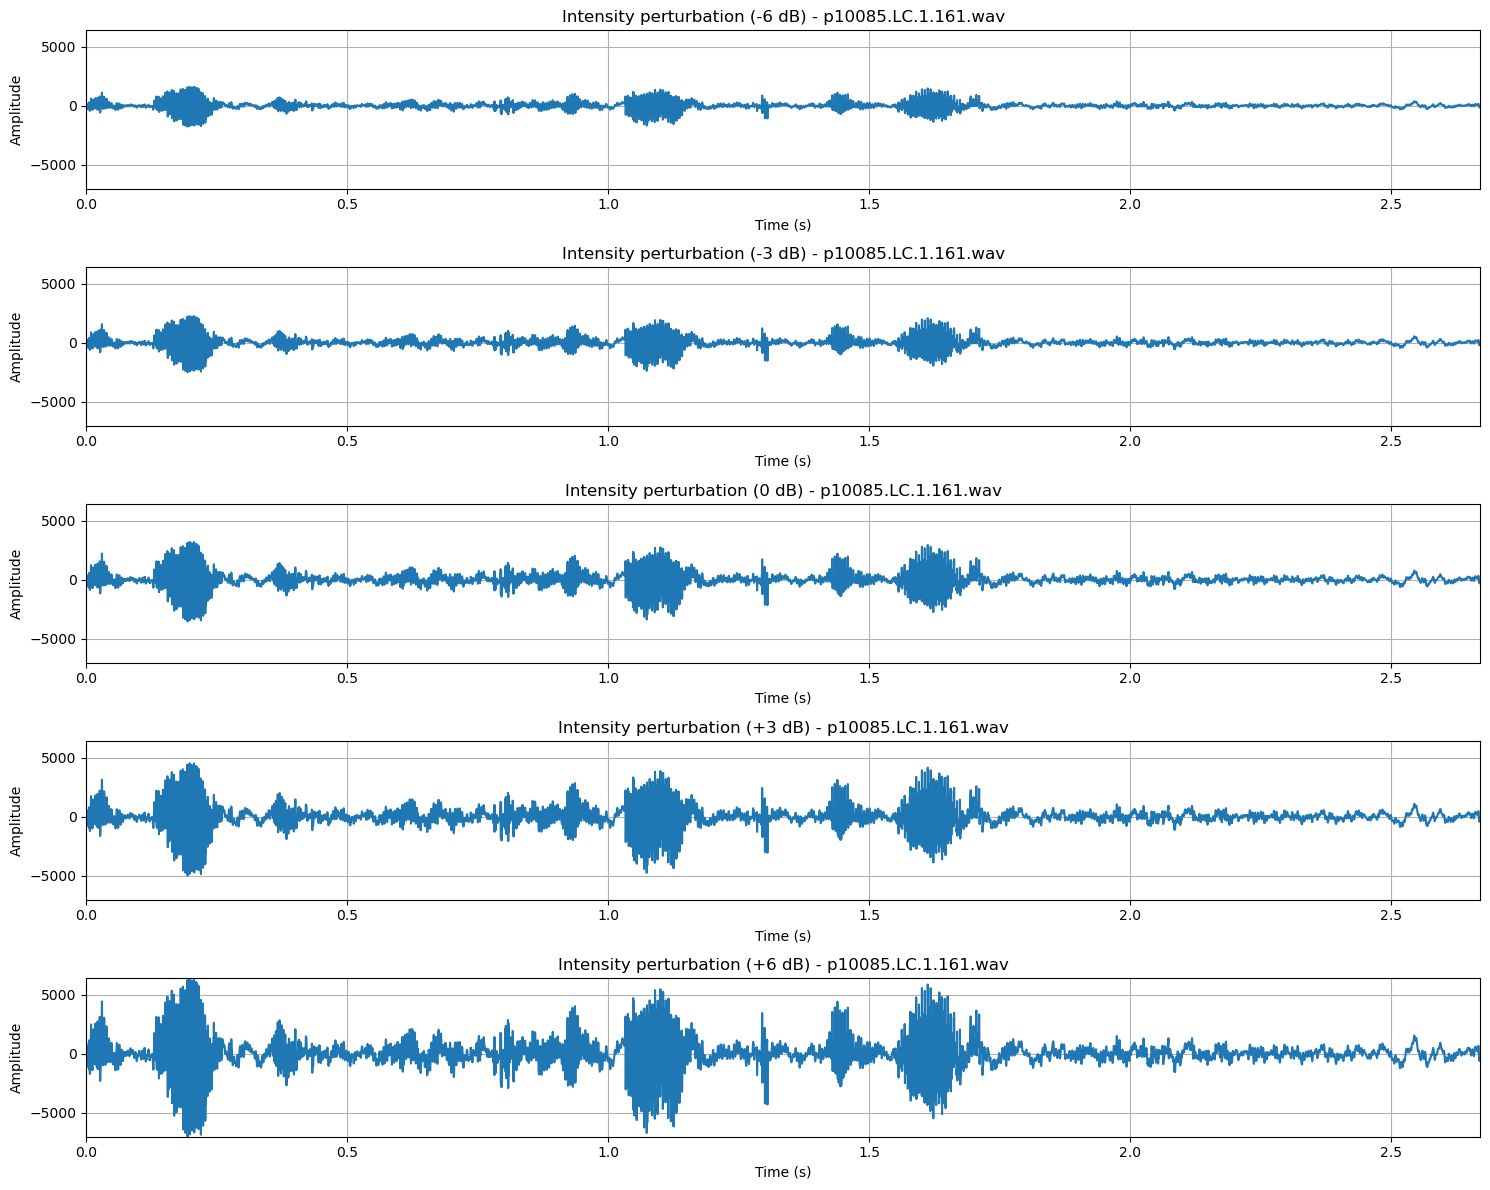

In [56]:
# Select participant and file
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)

perturbed_files = {
    "-6 dB": os.path.join(INTENSITY_OUTPUT_DIR, "-6dB", participant_id, filename),
    "-3 dB": os.path.join(INTENSITY_OUTPUT_DIR, "-3dB", participant_id, filename),
    "0 dB": original_file,
    "+3 dB": os.path.join(INTENSITY_OUTPUT_DIR, "+3dB", participant_id, filename),
    "+6 dB": os.path.join(INTENSITY_OUTPUT_DIR, "+6dB", participant_id, filename),
}

# Load signals and find global min/max for consistent y-axis scaling
signals = {}
global_min = np.inf
global_max = -np.inf

for label, file_path in perturbed_files.items():
    sample_rate, signal = load_wav_file(file_path)
    signal = signal.astype(np.float32)

    signals[label] = (sample_rate, signal)

    global_min = min(global_min, signal.min())
    global_max = max(global_max, signal.max())


# Plot
plt.figure(figsize=(15, 12))

for i, (label, (sample_rate, signal)) in enumerate(signals.items(), 1):

    time = np.arange(len(signal)) / sample_rate

    plt.subplot(5, 1, i)
    plt.plot(time, signal)
    plt.title(f"Intensity perturbation ({label}) - {filename}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, min(3, time[-1]))
    
    # Use the same amplitude scale for all plots
    plt.ylim(global_min, global_max)

    plt.grid(True)

plt.tight_layout()
plt.show()

In [3]:
# Standard libraries
from pathlib import Path
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import shutil


from scipy.io import wavfile
from scipy.signal import wiener

# load data
DATA_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME")
ORIGINAL_INPUT_DIR = DATA_PATH / "selected_original_audio_pain"
ORIGINAL_INTENSITY_OUTPUT_DIR = DATA_PATH / "original_intensity_perturbations_pain"

ORGINAL_INTENSITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#collect wav files
original_audio_files = []

for root, dirs, files in os.walk(ORIGINAL_INPUT_DIR):
    for file in files:
        if file.endswith(".wav"):
            original_audio_files.append(os.path.join(root, file))

print(f"Number of Original audio files: {len(original_audio_files)}")

Number of Original audio files: 1055


In [4]:
def load_wav_file(file_path):
    """
    Load a WAV file and return sample rate and signal.
    """
    sample_rate, signal = wavfile.read(file_path)
    return sample_rate, signal


def save_wav_file(file_path, sample_rate, signal):
    """
    Save a WAV file as int16.
    """
    signal = np.clip(signal, -32768, 32767) #so the signal remains in the 16 bit format 
    signal = signal.astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)

def change_audio_intensity(signal, gain_db):
    """
    Change audio intensity by applying gain in dB.

    Parameters
    signal : np.ndarray
        Input audio signal
    gain_db : float
        Gain in decibels

    Returns
    adjusted_signal : np.ndarray
        Intensity-adjusted audio signal
    """
    signal = signal.astype(np.float32)

    # Convert dB to linear amplitude factor
    gain_factor = 10 ** (gain_db / 20.0)

    adjusted_signal = signal * gain_factor
    return adjusted_signal


def make_perturbation_output_path(input_path, input_root, output_root, perturbation_name):
    """
    Save perturbed audio in:
    output_root / perturbation_name / PID / original_filename.wav
    """
    relative_path = os.path.relpath(input_path, input_root)
    output_path = os.path.join(output_root, perturbation_name, relative_path)

    output_dir = os.path.dirname(output_path)
    os.makedirs(output_dir, exist_ok=True)

    return output_path

In [5]:
# dB steps
step_dB = 3

perturbations = {
    "-6dB": -2 * step_dB,   # -6 dB
    "-3dB":  -1 * step_dB,   # -3 dB
    "+3dB":    1 * step_dB,   # +3 dB
    "+6dB":   2 * step_dB    # +6 dB
}

In [6]:
#save the different levels of dB in a new map 
processed_rows = []

for input_path in original_audio_files:
    try:
        sample_rate, signal = load_wav_file(input_path)

        for perturbation_name, gain_db in perturbations.items():
            adjusted_signal = change_audio_intensity(signal, gain_db)

            output_path = make_perturbation_output_path(
                input_path=input_path,
                input_root=ORIGINAL_INPUT_DIR,
                output_root=ORGINAL_INTENSITY_OUTPUT_DIR,
                perturbation_name=perturbation_name
            )

            save_wav_file(output_path, sample_rate, adjusted_signal)

            participant_id = os.path.basename(os.path.dirname(input_path))
            filename = os.path.basename(input_path)

            processed_rows.append({
                "participant_id": participant_id,
                "filename": filename,
                "original_file_path": input_path,
                "perturbation": perturbation_name,
                "gain_db": gain_db,
                "perturbed_file_path": output_path
            })

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

print(os.path.exists(input_path))

True


In [8]:
#check if number of processed files is correct
expected_files_per_perturbation = len(original_audio_files)
for perturbation_name in perturbations.keys():
    count = sum(1 for row in processed_rows if row["perturbation"] == perturbation_name)
    print(f"Number of files processed for {perturbation_name}: {count} (Expected: {expected_files_per_perturbation})")

Number of files processed for -6dB: 1055 (Expected: 1055)
Number of files processed for -3dB: 1055 (Expected: 1055)
Number of files processed for +3dB: 1055 (Expected: 1055)
Number of files processed for +6dB: 1055 (Expected: 1055)


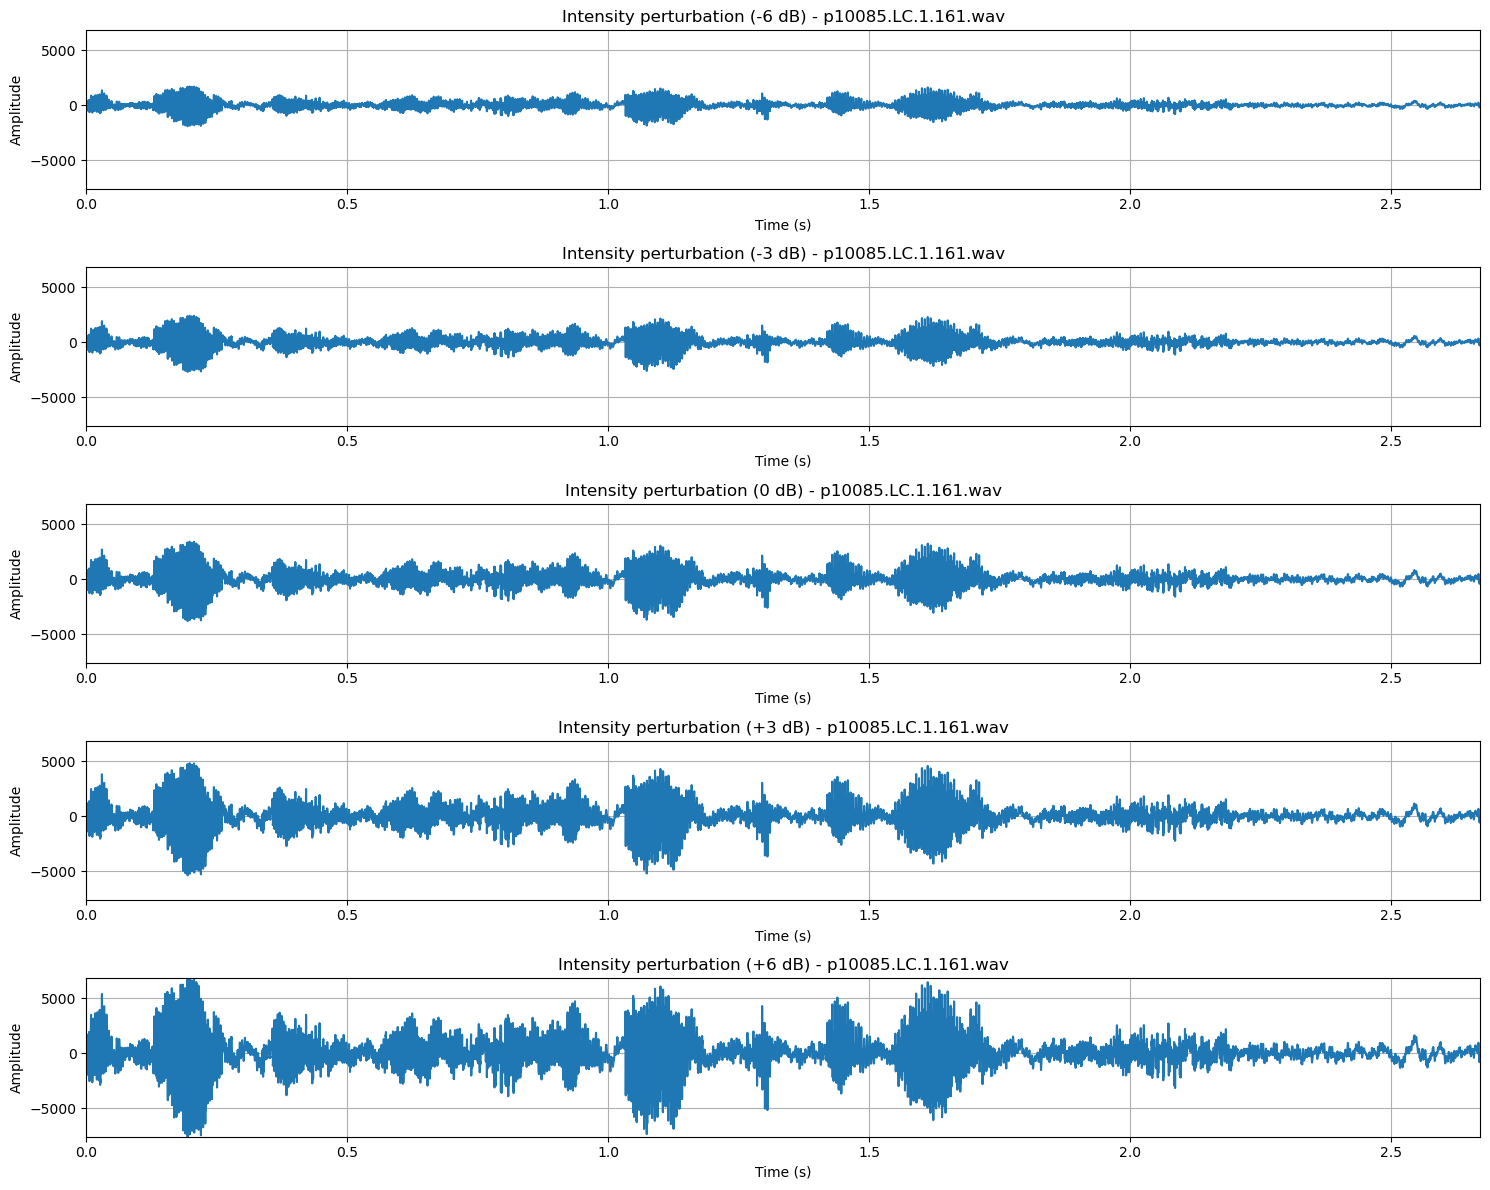

In [10]:
# Select participant and file
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(ORIGINAL_INPUT_DIR, participant_id, filename)

perturbed_files = {
    "-6 dB": os.path.join(ORIGINAL_INTENSITY_OUTPUT_DIR, "-6dB", participant_id, filename),
    "-3 dB": os.path.join(ORIGINAL_INTENSITY_OUTPUT_DIR, "-3dB", participant_id, filename),
    "0 dB": original_file,
    "+3 dB": os.path.join(ORIGINAL_INTENSITY_OUTPUT_DIR, "+3dB", participant_id, filename),
    "+6 dB": os.path.join(ORIGINAL_INTENSITY_OUTPUT_DIR, "+6dB", participant_id, filename),
}

# Load signals and find global min/max for consistent y-axis scaling
signals = {}
global_min = np.inf
global_max = -np.inf

for label, file_path in perturbed_files.items():
    sample_rate, signal = load_wav_file(file_path)
    signal = signal.astype(np.float32)

    signals[label] = (sample_rate, signal)

    global_min = min(global_min, signal.min())
    global_max = max(global_max, signal.max())


# Plot
plt.figure(figsize=(15, 12))

for i, (label, (sample_rate, signal)) in enumerate(signals.items(), 1):

    time = np.arange(len(signal)) / sample_rate

    plt.subplot(5, 1, i)
    plt.plot(time, signal)
    plt.title(f"Intensity perturbation ({label}) - {filename}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, min(3, time[-1]))
    
    # Use the same amplitude scale for all plots
    plt.ylim(global_min, global_max)

    plt.grid(True)

plt.tight_layout()
plt.show()